# 다이캐스팅 공정 데이터 분석 — Product_Type 1
> **분석 대상**: Product_Type 1 전용 (Type 2 완전 제외)

> **구성**: 데이터 로드 → 중복 제거 → 결측값 처리 → 이상치 처리 → 타겟/파생변수 → 시각화 → 상관분석 → 모델링

> **이상치 처리 합의 (260303)**
> - Velocity=0 → 삭제
> - Cycle_Time 극단값 → 공정 지연 신호로 유지
> - 절사 기준 IQR / 1% / 0.5% 비교
> - Velocity_2 이상치 184건 → 추가 조사 중

> **SMOTE 미적용** — class_weight로 불균형 대응

## STEP 0. 라이브러리 임포트 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 (멀티헤더)
df_raw = pd.read_csv(
    "../../data/DieCasting_Quality_Raw_Data.csv",
    header=[0, 1]
)
print(f"원본 Shape: {df_raw.shape}")
df_raw.head(3)

원본 Shape: (7535, 57)


Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144       0.17      0.188         2.134   
1    1002            1    2      0.144       0.17      0.182         2.124   
2    2003            1    3      0.144       0.17      0.182         2.116   

                                                        ...     Defects  \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness   ... Blow_Hole_2   
0               214           0.008                 10  ...           0   
1               217           0.008                 11  ...           0   
2               214           0.008                 11  ...           0   

                                                                             \
  Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2 Crack_2 Scratch_2   
0       0      0             0               0          0       0         0   
1       0      0             0               0          0       0         0   
2       0      0             0               0          0       0         0   

                              
  Buring_Mark_2 Inclusions_2  
0             0            0  
1             0            0  
2             0            0  

[3 rows x 57 columns]

## STEP 1. 데이터 구조 파악

In [2]:
print("컬럼 그룹:", df_raw.columns.get_level_values(0).unique().tolist())
print(f"전체 컬럼 수: {len(df_raw.columns)}")
df_raw.info()

컬럼 그룹: ['Process', 'Sensor', 'Defects']
전체 컬럼 수: 57
<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 57 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   7535 non-null   int64  
 1   (Process, Product_Type)         7535 non-null   int64  
 2   (Process, Shot)                 7535 non-null   int64  
 3   (Process, Velocity_1)           7535 non-null   float64
 4   (Process, Velocity_2)           7535 non-null   float64
 5   (Process, Velocity_3)           7535 non-null   float64
 6   (Process, High_Velocity)        7535 non-null   float64
 7   (Process, Cylinder_Pressure)    7535 non-null   int64  
 8   (Process, Rapid_Rise_Time)      7535 non-null   float64
 9   (Process, Biscuit_Thickness )   7535 non-null   int64  
 10  (Process, Clamping_Force )      7535 non-null   int64  
 11  (Process, Cycle_Time)           7535 non-null   float6

In [3]:
df_raw.describe()

Process                                                      \
                 id Product_Type         Shot   Velocity_1   Velocity_2   
count  7.535000e+03  7535.000000  7535.000000  7535.000000  7535.000000   
mean   3.767454e+06     1.441672   453.798938     0.148219     0.168801   
std    2.175264e+06     0.496619   319.451698     0.007134     0.004720   
min    1.000000e+00     1.000000     0.000000     0.134000     0.158000   
25%    1.883893e+06     1.000000   195.000000     0.142000     0.166000   
50%    3.767193e+06     1.000000   401.000000     0.144000     0.168000   
75%    5.650924e+06     2.000000   645.000000     0.156000     0.170000   
max    7.534661e+06     2.000000  1296.000000     0.180000     0.212000   

                                                                    \
        Velocity_3 High_Velocity Cylinder_Pressure Rapid_Rise_Time   
count  7535.000000   7535.000000       7535.000000     7535.000000   
mean      0.191193      2.319210        239.655607        0.009596   
std       0.011563      0.222041         23.305451        0.002148   
min       0.172000      0.000000        107.000000        0.000000   
25%       0.181000      2.134000        217.000000        0.008000   
50%       0.188000      2.161000        239.000000        0.009000   
75%       0.202000      2.523000        265.000000        0.012000   
max       0.234000      2.744000        266.000000        0.021000   

                          ...      Defects                                     \
      Biscuit_Thickness   ...  Blow_Hole_2 Stain_2       Dent_2 Deformation_2   
count        7535.000000  ...  7535.000000  7535.0  7535.000000   7535.000000   
mean           14.309622  ...     0.021367     0.0     0.000531      0.008626   
std             3.286284  ...     0.150020     0.0     0.023036      0.093907   
min             0.000000  ...     0.000000     0.0     0.000000      0.000000   
25%            11.000000  ...     0.000000     0.0     0.000000      0.000000   
50%            13.000000  ...     0.000000     0.0     0.000000      0.000000   
75%            17.000000  ...     0.000000     0.0     0.000000      0.000000   
max            24.000000  ...     2.000000     0.0     1.000000      2.000000   

                                                                         \
      Contamination_2   Impurity_2      Crack_2 Scratch_2 Buring_Mark_2   
count     7535.000000  7535.000000  7535.000000    7535.0        7535.0   
mean         0.001062     0.000664     0.000265       0.0           0.0   
std          0.032569     0.025753     0.016291       0.0           0.0   
min          0.000000     0.000000     0.000000       0.0           0.0   
25%          0.000000     0.000000     0.000000       0.0           0.0   
50%          0.000000     0.000000     0.000000       0.0           0.0   
75%          0.000000     0.000000     0.000000       0.0           0.0   
max          1.000000     1.000000     1.000000       0.0           0.0   

                    
      Inclusions_2  
count  7535.000000  
mean      0.000133  
std       0.011520  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  

[8 rows x 57 columns]

In [4]:
df_raw.nunique()

Process  id                      7535
         Product_Type               2
         Shot                    1271
         Velocity_1                33
         Velocity_2                27
         Velocity_3                45
         High_Velocity            319
         Cylinder_Pressure         22
         Rapid_Rise_Time           18
         Biscuit_Thickness         24
         Clamping_Force            42
         Cycle_Time                61
          Pressure_Rise_Time       16
         Casting_Pressure          65
         Spray_Time                32
         Spray_1_Time               7
         Spray_2_Time               8
Sensor   Melting_Furnace_Temp     737
         Air_Pressure              26
         Air_Pressure_Min           1
         Air_Pressure_Max           1
         Coolant_Temp              23
         Coolant_Temp_Min           1
         Coolant_Temp_Max           1
         Coolant_Pressure          22
         Factory_Temp              67
         Fac

## STEP 2. 헤더 정리 & Product_Type 1 필터링
> 멀티헤더 → 단일헤더 변환 후 **Product_Type 1만 추출**

In [5]:
df = df_raw.copy()

# 멀티헤더 → 단일헤더
df.columns = df.columns.get_level_values(1).str.strip()

# 수치형 변환
df.iloc[:, 1:] = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

# ── Product_Type 1만 추출
df = df[df['Product_Type'] == 1].reset_index(drop=True)

print(f"✅ Product_Type 1 추출 완료: {df.shape[0]}행 × {df.shape[1]}열")
print(f"   전체 대비: {df.shape[0]}/7535행 ({df.shape[0]/7535*100:.1f}%)")

✅ Product_Type 1 추출 완료: 4207행 × 57열
   전체 대비: 4207/7535행 (55.8%)


## STEP 3. 중복 데이터 확인 및 제거
> id 제외 기준 완전 중복 행 탐지 후 제거

> **판단 근거**: Cavity 정보는 이미 _1/_2 컬럼으로 하나의 행에 통합되어 있어
> 완전 중복 행은 데이터 수집 오기로 판단

In [6]:
print(f"중복 제거 전: {df.shape[0]}행")
print(f"id 제외 중복 행 수: {df.drop(columns=['id']).duplicated().sum()}건")

# 중복 중 불량/양품 분포 확인
defect_cols_check = [c for c in df.columns if any(c.startswith(d) for d in [
    'Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain','Dent',
    'Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions'
])]
dup_mask = df.drop(columns=['id']).duplicated(keep=False)
dup_rows = df[dup_mask]
print(f"중복 행 중 불량: {(dup_rows[defect_cols_check].sum(axis=1)>0).sum()}건")
print(f"중복 행 중 양품: {(dup_rows[defect_cols_check].sum(axis=1)==0).sum()}건")

중복 제거 전: 4207행
id 제외 중복 행 수: 1554건
중복 행 중 불량: 326건
중복 행 중 양품: 2782건


In [7]:
# 중복 제거 (첫 번째 행 유지)
before = df.shape[0]
dedup_cols = [c for c in df.columns if c != 'id']
df = df.drop_duplicates(subset=dedup_cols, keep='first').reset_index(drop=True)

print(f"✅ 중복 제거 완료")
print(f"   제거 전: {before}행 → 제거 후: {df.shape[0]}행 (제거: {before - df.shape[0]}건)")

✅ 중복 제거 완료
   제거 전: 4207행 → 제거 후: 2653행 (제거: 1554건)


## STEP 4. 결측값 확인 및 처리

In [8]:
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
if len(missing_cols) == 0:
    print("결측값 없음")
else:
    print("결측값 보유 컬럼:")
    display(pd.DataFrame({'missing_count': missing_cols,
                          'missing_ratio(%)': (missing_cols/len(df)*100).round(2)}))

결측값 없음


In [9]:
# Factory 센서 결측값 → 중앙값 대체 (Product_Type 1 단일이므로 전체 중앙값 사용)
factory_cols = [
    'Factory_Temp','Factory_Temp_Min','Factory_Temp_Max',
    'Factory_Humidity','Factory_Humidity_Min','Factory_Humidity_Max'
]
for col in factory_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print(f"✅ 결측값 처리 완료 → 잔여 결측값: {df.isnull().sum().sum()}건")

✅ 결측값 처리 완료 → 잔여 결측값: 0건


## STEP 5. 이상치 탐지 및 처리
> **처리 순서**
> 1. 분산=0 변수 사전 확인 → Capping 대상에서 제외 (IQR=0이면 과도한 Capping 발생)
> 2. Velocity=0 → 삭제
> 3. Cycle_Time → Capping 제외 (공정 지연 신호)
> 4. 절사 기준 IQR / 1% / 0.5% 비교 후 IQR 적용
> 5. Velocity_2 이상치 → 추가 조사 중 (IQR 유지)

In [10]:
# 이상치 탐지 함수
def detect_outliers_iqr(dataframe, cols):
    outlier_info = {}
    for col in cols:
        Q1, Q3 = dataframe[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        mask = (dataframe[col] < lower) | (dataframe[col] > upper)
        outlier_info[col] = {
            'count': mask.sum(),
            'pct(%)': f"{mask.mean()*100:.2f}",
            'lower_bound': round(lower, 3),
            'upper_bound': round(upper, 3)
        }
    result = pd.DataFrame(outlier_info).T.sort_values('count', ascending=False)
    return result[result['count'] > 0]

process_num_cols = [
    'Velocity_1','Velocity_2','Velocity_3','High_Velocity',
    'Cylinder_Pressure','Rapid_Rise_Time','Biscuit_Thickness',
    'Clamping_Force','Cycle_Time','Pressure_Rise_Time',
    'Casting_Pressure','Spray_Time','Spray_1_Time','Spray_2_Time'
]

# ── 분산=0 또는 IQR=0 변수 사전 확인 → Capping 대상에서 제외
zero_var_cols = []
for col in process_num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    if df[col].std() == 0 or df[col].nunique() <= 1 or IQR == 0:
        zero_var_cols.append(col)

if zero_var_cols:
    print(f"⚠️  IQR=0 또는 분산=0 변수 발견 → Capping 대상 제외: {zero_var_cols}")
    for col in zero_var_cols:
        print(f"   {col}: 고유값={df[col].nunique()}, IQR={df[col].quantile(0.75)-df[col].quantile(0.25):.4f}")
else:
    print("✅ 분산=0 / IQR=0 변수 없음")

# Capping 가능한 컬럼만 추출 (IQR=0 + Cycle_Time 제외)
cap_cols = [c for c in process_num_cols if c != 'Cycle_Time' and c not in zero_var_cols]
print(f"\nCapping 대상 컬럼 ({len(cap_cols)}개): {cap_cols}")

print("\n[ Process 변수 이상치 탐지 (IQR=0 제외) ]")
display(detect_outliers_iqr(df, cap_cols))
print("\n※ Cycle_Time → Capping 제외 (공정 지연 신호 유지)")
print("※ Velocity_2 이상치 → 추가 조사 중 (현재 IQR Capping 유지)")
if zero_var_cols:
    print(f"※ {zero_var_cols} → IQR=0으로 Capping 제외 (이후 피처에서도 제거)")

⚠️  IQR=0 또는 분산=0 변수 발견 → Capping 대상 제외: ['Rapid_Rise_Time', 'Spray_2_Time']
   Rapid_Rise_Time: 고유값=18, IQR=0.0000
   Spray_2_Time: 고유값=3, IQR=0.0000

Capping 대상 컬럼 (11개): ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Biscuit_Thickness', 'Clamping_Force', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time']

[ Process 변수 이상치 탐지 (IQR=0 제외) ]


,count,pct(%),lower_bound,upper_bound
Cylinder_Pressure,357,13.46,210.5,222.5
Casting_Pressure,357,13.46,1015.0,1079.0
Spray_Time,324,12.21,7.3,8.9
Pressure_Rise_Time,284,10.70,0.037,0.048
Biscuit_Thickness,203,7.65,9.5,13.5
Velocity_1,139,5.24,0.139,0.147
Velocity_2,103,3.88,0.165,0.173
High_Velocity,95,3.58,2.075,2.2
Velocity_3,72,2.71,0.167,0.196
Clamping_Force,13,0.49,248.0,264.0



※ Cycle_Time → Capping 제외 (공정 지연 신호 유지)
※ Velocity_2 이상치 → 추가 조사 중 (현재 IQR Capping 유지)
※ ['Rapid_Rise_Time', 'Spray_2_Time'] → IQR=0으로 Capping 제외 (이후 피처에서도 제거)


In [11]:
# Velocity=0 삭제
#velocity_cols = ['Velocity_1','Velocity_2','Velocity_3','High_Velocity']
zero_mask = (df['High_Velocity'] == 0)
print(f"Velocity=0 행 삭제: {zero_mask.sum()}건")
df = df[~zero_mask].reset_index(drop=True)

# 절사 기준 비교 (cap_cols 기준 — 분산=0 이미 제외됨)
def count_outliers(dataframe, cols, method='iqr', pct=0.01):
    result = {}
    for col in cols:
        if method == 'iqr':
            Q1, Q3 = dataframe[col].quantile(0.25), dataframe[col].quantile(0.75)
            IQR = Q3 - Q1
            lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        else:
            lower = dataframe[col].quantile(pct)
            upper = dataframe[col].quantile(1 - pct)
        result[col] = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
    return pd.Series(result)

compare_df = pd.DataFrame({
    'IQR':  count_outliers(df, cap_cols, 'iqr'),
    '1%':   count_outliers(df, cap_cols, 'pct', 0.01),
    '0.5%': count_outliers(df, cap_cols, 'pct', 0.005),
}).sort_values('IQR', ascending=False)

print("[ 절사 기준별 이상치 건수 비교 ]")
print("(분산=0 변수 및 Cycle_Time 제외)")
display(compare_df[compare_df.sum(axis=1) > 0])

# IQR Capping 적용
outlier_report = []
for col in cap_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    cnt = ((df[col] < lower) | (df[col] > upper)).sum()
    if cnt > 0:
        outlier_report.append({'변수': col, '이상치 수': cnt})
    df[col] = df[col].clip(lower, upper)

print("\n✅ IQR Capping 완료:")
for r in outlier_report:
    flag = " ⚠️ 추가 조사 중" if r['변수'] == 'Velocity_2' else ""
    print(f"   - {r['변수']}: {r['이상치 수']}건{flag}")
if zero_var_cols:
    print(f"   - {zero_var_cols}: 분산=0으로 Capping 미적용")
print(f"\n최종 데이터: {df.shape[0]}행 × {df.shape[1]}열")


Velocity=0 행 삭제: 2건
[ 절사 기준별 이상치 건수 비교 ]
(분산=0 변수 및 Cycle_Time 제외)


,IQR,1%,0.5%
Cylinder_Pressure,355,8,8
Casting_Pressure,355,13,13
Spray_Time,324,38,23
Pressure_Rise_Time,282,9,9
Biscuit_Thickness,202,37,24
Velocity_1,139,37,24
Velocity_2,103,24,15
High_Velocity,93,53,28
Velocity_3,72,34,24
Clamping_Force,12,38,19



✅ IQR Capping 완료:
   - Velocity_1: 139건
   - Velocity_2: 103건 ⚠️ 추가 조사 중
   - Velocity_3: 72건
   - High_Velocity: 93건
   - Cylinder_Pressure: 355건
   - Biscuit_Thickness: 202건
   - Clamping_Force: 12건
   - Pressure_Rise_Time: 282건
   - Casting_Pressure: 355건
   - Spray_Time: 324건
   - ['Rapid_Rise_Time', 'Spray_2_Time']: 분산=0으로 Capping 미적용

최종 데이터: 2651행 × 57열


## STEP 6. 타겟 변수 및 파생변수 생성

In [12]:
# 타겟 변수
defect_cols_all = [c for c in df.columns if any(c.startswith(d) for d in [
    'Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain','Dent',
    'Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions'
])]
df['Defect_Status'] = (df[defect_cols_all].sum(axis=1) > 0).astype(int)

defect_types = {
    'Short_Shot':  ['Short_Shot_1','Short_Shot_2'],
    'Blow_Hole':   ['Blow_Hole_1','Blow_Hole_2'],
    'Exfoliation': ['Exfoliation_1','Exfoliation_2'],
    'Stain':       ['Stain_1','Stain_2'],
    'Deformation': ['Deformation_1','Deformation_2'],
    'Bubble':      ['Bubble_1','Bubble_2'],
    'Other': ['Dent_1','Dent_2','Contamination_1','Contamination_2',
              'Impurity_1','Impurity_2','Crack_1','Crack_2',
              'Scratch_1','Scratch_2','Buring_Mark_1','Buring_Mark_2',
              'Inclusions_1','Inclusions_2']
}

def get_defect_label(row):
    if row['Defect_Status'] == 0: return 'Normal'
    for label, cols in defect_types.items():
        valid = [c for c in cols if c in row.index]
        if row[valid].sum() > 0: return label
    return 'Other'

df['Defect_Type'] = df.apply(get_defect_label, axis=1)

print("✅ 타겟 변수 생성 완료")
print(f"\n[Defect_Status 분포]")
print(df['Defect_Status'].value_counts().to_string())
print(f"\n불량률: {df['Defect_Status'].mean()*100:.1f}%")
print(f"\n[Defect_Type 분포]")
print(df['Defect_Type'].value_counts().to_string())

✅ 타겟 변수 생성 완료

[Defect_Status 분포]
Defect_Status
0    2075
1     576

불량률: 21.7%

[Defect_Type 분포]
Defect_Type
Normal         2075
Exfoliation     196
Short_Shot      165
Deformation     152
Bubble           58
Other             3
Stain             2


In [13]:
# 파생변수
df['Pressure_Diff'] = df['Casting_Pressure'] - df['Cylinder_Pressure']
print("✅ 파생변수 생성 완료")
print("   - Pressure_Diff: Casting_Pressure - Cylinder_Pressure")

✅ 파생변수 생성 완료
   - Pressure_Diff: Casting_Pressure - Cylinder_Pressure


## STEP 7. 변수별 분포 시각화

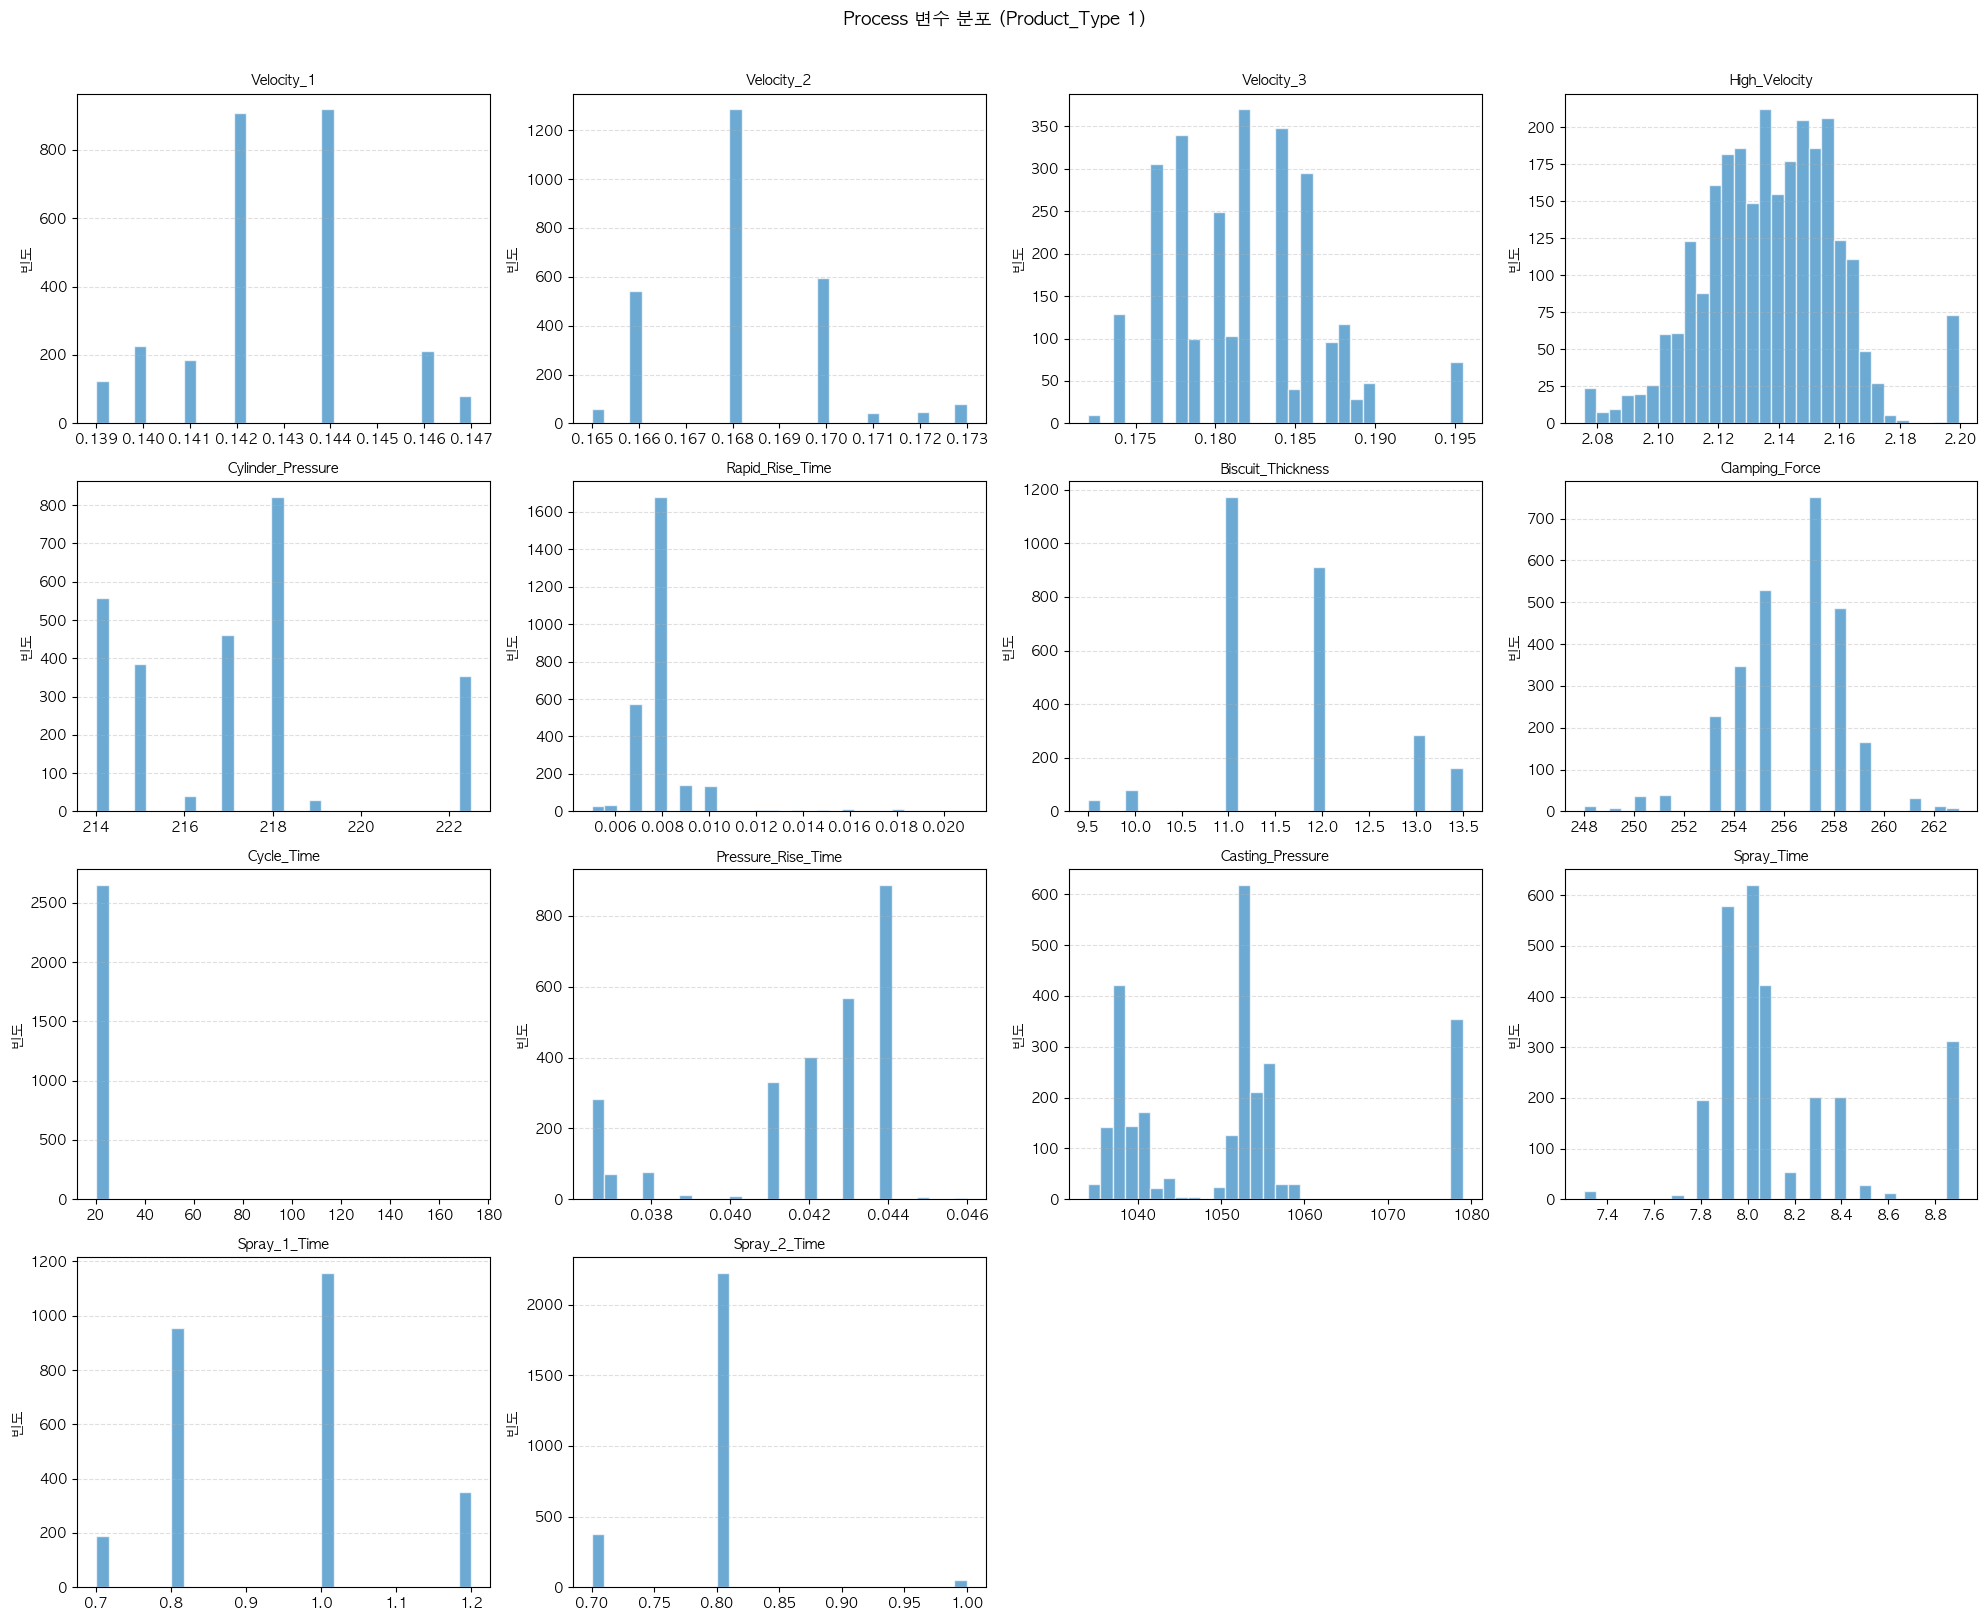

In [14]:
# Process 변수 히스토그램 + 박스플롯
n_cols, n_rows = 4, (len(process_num_cols) + 3) // 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(process_num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#2E86C1', alpha=0.7, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('빈도')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Process 변수 분포 (Product_Type 1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

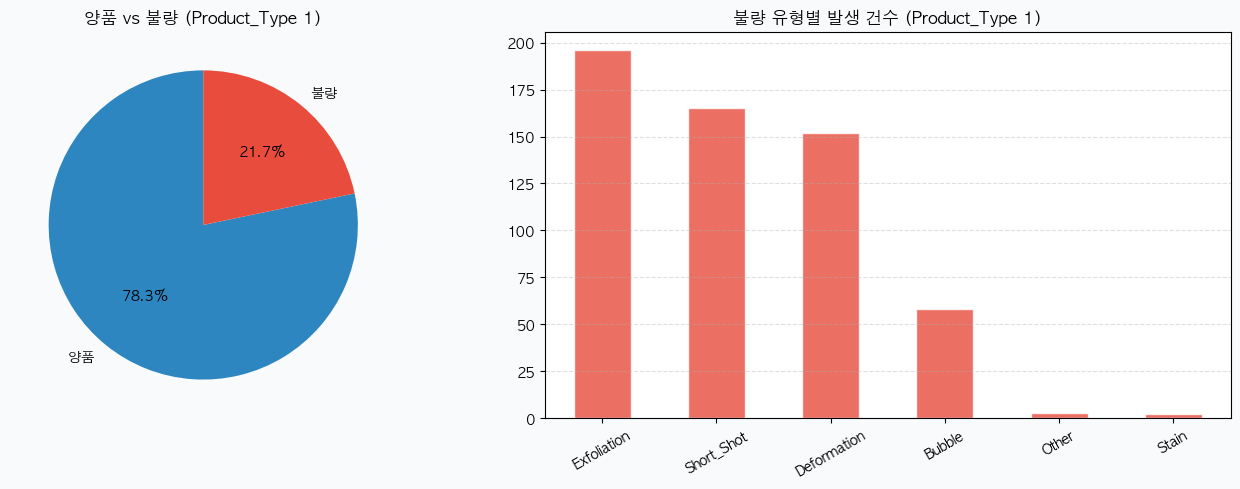

In [15]:
# 불량 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8FAFB')

# 파이 차트
sizes = df['Defect_Status'].value_counts()
axes[0].pie(sizes, labels=['양품','불량'], autopct='%1.1f%%',
            colors=['#2E86C1','#E74C3C'], startangle=90)
axes[0].set_title(f'양품 vs 불량 (Product_Type 1)', fontweight='bold')

# 불량 유형 바 차트
defect_counts = df[df['Defect_Status']==1]['Defect_Type'].value_counts()
defect_counts.plot(kind='bar', ax=axes[1], color='#E74C3C', alpha=0.8, edgecolor='white')
axes[1].set_title('불량 유형별 발생 건수 (Product_Type 1)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## STEP 8. 전처리 완료 데이터 저장

In [16]:
save_cols = (
    ['id','Product_Type','Shot']
    + process_num_cols
    + ['Melting_Furnace_Temp','Air_Pressure','Coolant_Temp',
       'Coolant_Pressure','Factory_Temp','Factory_Humidity']
    + ['Pressure_Diff']
    + ['Defect_Status','Defect_Type']
)
df_clean = df[save_cols].copy()
df_clean.to_csv('DieCasting_Preprocessed_Type1.csv', index=False)

print(f"✅ 저장 완료: DieCasting_Preprocessed_Type1.csv")
print(f"   최종 Shape: {df_clean.shape[0]}행 × {df_clean.shape[1]}열")
df_clean.head(3)

✅ 저장 완료: DieCasting_Preprocessed_Type1.csv
   최종 Shape: 2651행 × 26열


,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Pressure_Diff,Defect_Status,Defect_Type
0,1,1,1,0.144,0.17,0.188,2.134,214.0,0.008,10.0,...,0.8,695.0,6.3,26.0,2.71,32.9,58.4,823.0,0,Normal
1,1002,1,2,0.144,0.17,0.182,2.124,217.0,0.008,11.0,...,0.8,696.4,6.3,26.1,2.69,32.9,58.2,835.0,0,Normal
2,2003,1,3,0.144,0.17,0.182,2.116,214.0,0.008,11.0,...,0.8,696.4,6.3,26.1,2.69,32.9,58.2,823.0,0,Normal


## STEP 9. 상관분석 — Defect_Status와의 Pearson 상관계수
> Product_Type 1 데이터만으로 계산한 상관계수 (전체 혼합 대비 더 정확)

In [ ]:
analysis_features = (
    process_num_cols
    + ['Melting_Furnace_Temp','Air_Pressure','Coolant_Temp','Coolant_Pressure',
       'Factory_Temp','Factory_Humidity']
    + ['Pressure_Diff']
)

# 분산=0 변수는 상관분석에서도 제외
analysis_features = [f for f in analysis_features if f not in zero_var_cols]

corr_series = df[analysis_features + ['Defect_Status']].corr()['Defect_Status'].drop('Defect_Status')
corr_df = pd.DataFrame({
    'variable':    corr_series.index,
    'correlation': corr_series.values,
    'abs_corr':    corr_series.abs().values
}).sort_values('abs_corr', ascending=False).reset_index(drop=True)
corr_df.insert(0, 'rank', range(1, len(corr_df)+1))

print("Defect_Status와의 Sperman 상관계수 전체 순위 (Product_Type 1):")
if zero_var_cols:
    print(f"   (분산=0으로 제외된 변수: {zero_var_cols})")
display(corr_df)


📊 Defect_Status와의 Pearson 상관계수 전체 순위 (Product_Type 1):
   (분산=0으로 제외된 변수: ['Rapid_Rise_Time', 'Spray_2_Time'])


,rank,variable,correlation,abs_corr
0,1,Factory_Humidity,-0.302714,0.302714
1,2,Factory_Temp,0.247672,0.247672
2,3,Spray_Time,-0.178563,0.178563
3,4,Pressure_Diff,-0.165197,0.165197
4,5,Biscuit_Thickness,-0.163961,0.163961
5,6,Casting_Pressure,-0.163911,0.163911
6,7,Cylinder_Pressure,-0.157059,0.157059
7,8,Pressure_Rise_Time,0.134833,0.134833
8,9,Air_Pressure,0.104421,0.104421
9,10,Clamping_Force,0.079949,0.079949


### ⚠️ 상관계수 NaN 변수 처리
> 상관계수가 NaN인 변수 = 분산이 0 (상수값) → 예측에 기여 불가
> 모델 피처에서 제거 필요

In [18]:
# NaN 상관계수 잔여 확인 (분산=0 변수를 Capping 전에 제거했으므로 NaN 없어야 함)
nan_vars = corr_df[corr_df['correlation'].isna()]['variable'].tolist()

if not nan_vars:
    print("✅ NaN 상관계수 없음 — 분산=0 변수 사전 제거 효과")
else:
    print(f"⚠️ 잔여 NaN 변수: {nan_vars}")
    for col in nan_vars:
        print(f"   {col}: 고유값={df[col].nunique()}, std={df[col].std():.6f}")


✅ NaN 상관계수 없음 — 분산=0 변수 사전 제거 효과


In [19]:
# 분산=0 변수 제거 (Capping 단계에서 이미 cap_cols에서 제외됨 — 여기서 FEATURES에도 반영)
print(f"분산=0으로 제거된 변수: {zero_var_cols}")

FEATURES = [f for f in (
    process_num_cols
    + ['Melting_Furnace_Temp','Air_Pressure','Coolant_Temp','Coolant_Pressure',
       'Factory_Temp','Factory_Humidity']
    + ['Velocity_Avg','Pressure_Diff','Coolant_Temp_Range']
) if f not in zero_var_cols]

print(f"\n✅ 정제된 피처 수: {len(FEATURES)}개")
print(f"   사용 피처: {FEATURES}")


분산=0으로 제거된 변수: ['Rapid_Rise_Time', 'Spray_2_Time']

✅ 정제된 피처 수: 21개
   사용 피처: ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Velocity_Avg', 'Pressure_Diff', 'Coolant_Temp_Range']


In [20]:
# 다중공선성 확인 — Casting_Pressure / Cylinder_Pressure / Pressure_Diff
high_corr_vars = ['Casting_Pressure', 'Cylinder_Pressure', 'Pressure_Diff']
print("[ 다중공선성 의심 변수 상관관계 ]")
display(df[high_corr_vars].corr().round(3))
print()
print("※ 상관계수 0.99 → 셋 중 Pressure_Diff(파생변수)만 유지 권장")
print("  Pressure_Diff = Casting_Pressure - Cylinder_Pressure")
print("  → 두 압력의 차이가 실질적인 정보를 담고 있음")

[ 다중공선성 의심 변수 상관관계 ]


,Casting_Pressure,Cylinder_Pressure,Pressure_Diff
Casting_Pressure,1.000,0.992,0.999
Cylinder_Pressure,0.992,1.000,0.987
Pressure_Diff,0.999,0.987,1.000



※ 상관계수 0.99 → 셋 중 Pressure_Diff(파생변수)만 유지 권장
  Pressure_Diff = Casting_Pressure - Cylinder_Pressure
  → 두 압력의 차이가 실질적인 정보를 담고 있음


In [21]:
# 다중공선성 변수 정리 — Casting_Pressure, Cylinder_Pressure 제거
multicollinear_cols = ['Casting_Pressure', 'Cylinder_Pressure']

FEATURES = [f for f in FEATURES if f not in multicollinear_cols]

print(f"✅ 다중공선성 제거 후 최종 피처 수: {len(FEATURES)}개")
print(f"   제거: {multicollinear_cols}")
print(f"   유지: Pressure_Diff (두 압력의 차이 = 실질 정보)")
print(f"\n최종 FEATURES: {FEATURES}")

✅ 다중공선성 제거 후 최종 피처 수: 19개
   제거: ['Casting_Pressure', 'Cylinder_Pressure']
   유지: Pressure_Diff (두 압력의 차이 = 실질 정보)

최종 FEATURES: ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time', 'Spray_Time', 'Spray_1_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Velocity_Avg', 'Pressure_Diff', 'Coolant_Temp_Range']


In [22]:
top10 = corr_df.head(10).copy()
print("🏆 TOP 10 변수 (|상관계수| 기준)")
print("-" * 50)
for _, row in top10.iterrows():
    direction = "▼ 불량 감소" if row['correlation'] < 0 else "▲ 불량 증가"
    print(f"  #{int(row['rank']):2d}  {row['variable']:<25}  {row['correlation']:+.4f}  {direction}")

🏆 TOP 10 변수 (|상관계수| 기준)
--------------------------------------------------
  # 1  Factory_Humidity           -0.3027  ▼ 불량 감소
  # 2  Factory_Temp               +0.2477  ▲ 불량 증가
  # 3  Spray_Time                 -0.1786  ▼ 불량 감소
  # 4  Pressure_Diff              -0.1652  ▼ 불량 감소
  # 5  Biscuit_Thickness          -0.1640  ▼ 불량 감소
  # 6  Casting_Pressure           -0.1639  ▼ 불량 감소
  # 7  Cylinder_Pressure          -0.1571  ▼ 불량 감소
  # 8  Pressure_Rise_Time         +0.1348  ▲ 불량 증가
  # 9  Air_Pressure               +0.1044  ▲ 불량 증가
  #10  Clamping_Force             +0.0799  ▲ 불량 증가


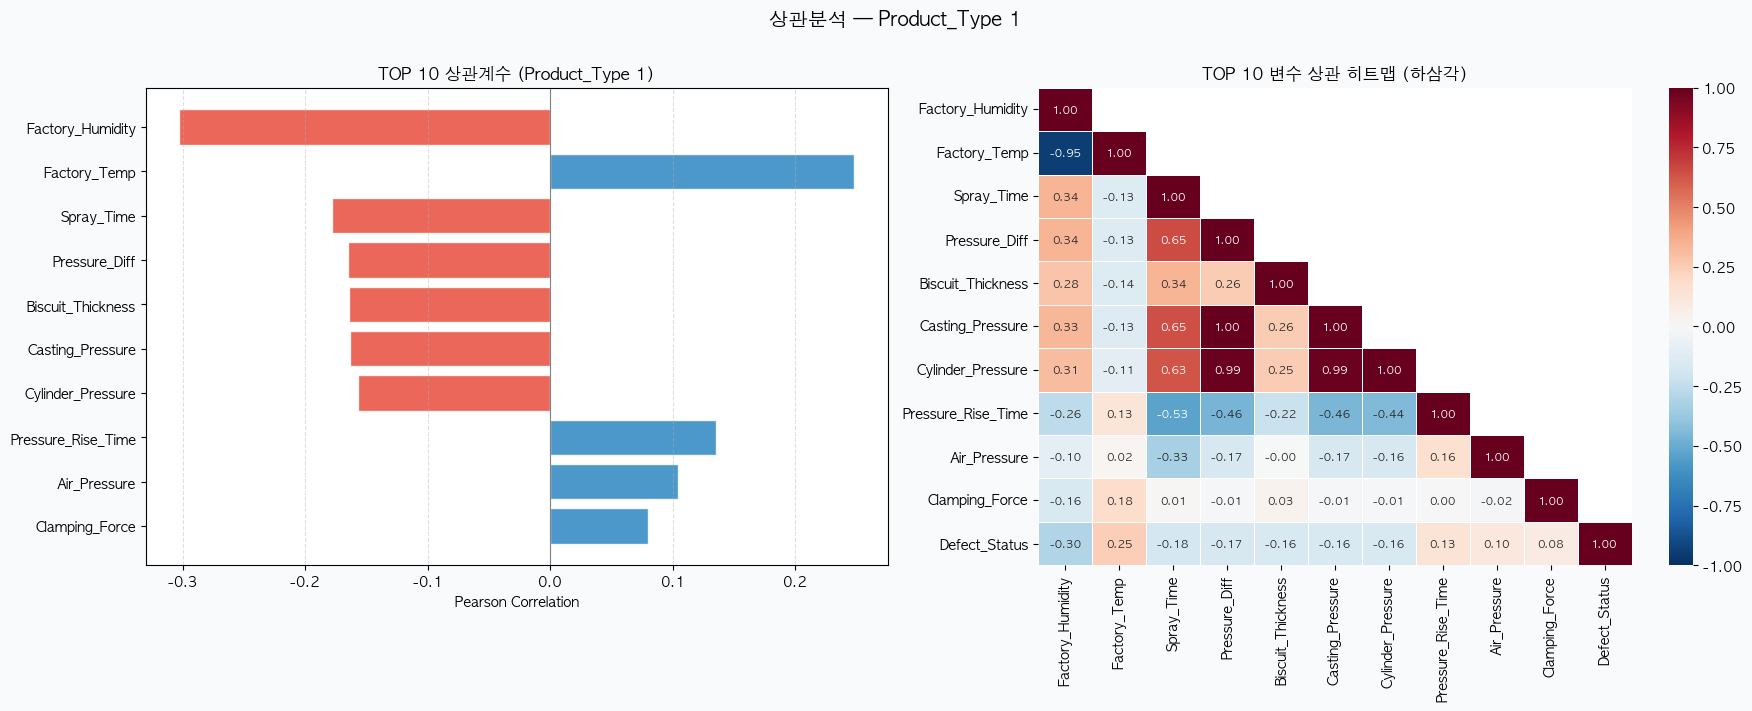

In [23]:
# 상관계수 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#F8FAFB')

# 바 차트
colors = ['#E74C3C' if v < 0 else '#2E86C1' for v in top10['correlation']]
axes[0].barh(top10['variable'][::-1], top10['correlation'][::-1],
             color=colors[::-1], alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='gray', lw=0.8)
axes[0].set_title('TOP 10 상관계수 (Product_Type 1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pearson Correlation')
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

# 히트맵
top10_vars = top10['variable'].tolist()
corr_matrix = df[top10_vars + ['Defect_Status']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, ax=axes[1], annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 8}, linewidths=0.5)
axes[1].set_title('TOP 10 변수 상관 히트맵 (하삼각)', fontsize=12, fontweight='bold')

plt.suptitle('상관분석 — Product_Type 1', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 🤖 모델링 파이프라인 (Product_Type 1)
> **목표**: Recall ≥ 0.80 유지하면서 F1-Score 최대화

> **SMOTE 미적용** — class_weight / scale_pos_weight로 불균형 대응

## STEP 10. 모델링 라이브러리 임포트

In [24]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, recall_score, precision_score,
    precision_recall_curve, average_precision_score
)
import xgboost as xgb
import lightgbm as lgb
import shap
import pickle

SEED = 42
np.random.seed(SEED)
print("✅ 모델링 라이브러리 로드 완료")

✅ 모델링 라이브러리 로드 완료


## STEP 11. 피처 및 타겟 정의

In [25]:
FEATURES = (
    process_num_cols
    + ['Melting_Furnace_Temp','Air_Pressure','Coolant_Temp','Coolant_Pressure',
       'Factory_Temp','Factory_Humidity']
    + ['Pressure_Diff']
    # Product_Type 제외 (단일 Type이므로 불필요)
)

X = df[FEATURES].copy()
y = df['Defect_Status'].copy()

print(f"📌 피처 수: {len(FEATURES)}개")
print(f"📌 타겟 분포 → 양품: {(y==0).sum()} / 불량: {(y==1).sum()} ({y.mean()*100:.1f}%)")

📌 피처 수: 21개
📌 타겟 분포 → 양품: 2075 / 불량: 576 (21.7%)


## STEP 12. Train/Test Split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

pos_weight = (y_train==0).sum() / (y_train==1).sum()

print(f"훈련셋: {X_train.shape[0]}행  |  테스트셋: {X_test.shape[0]}행")
print(f"훈련셋 불량률: {y_train.mean()*100:.1f}%  |  테스트셋 불량률: {y_test.mean()*100:.1f}%")
print(f"scale_pos_weight: {pos_weight:.2f}")

훈련셋: 2120행  |  테스트셋: 531행
훈련셋 불량률: 21.7%  |  테스트셋 불량률: 21.7%
scale_pos_weight: 3.60


## STEP 13. 베이스라인 모델 비교

In [27]:
def find_best_threshold_constrained(y_true, y_prob, target_recall=0.80,
                                    thr_min=0.05, thr_max=0.95, step=0.01):
    thresholds = np.arange(thr_min, thr_max + 1e-9, step)
    best, best_any = None, None
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        r  = recall_score(y_true, y_pred, zero_division=0)
        p  = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        row = (thr, r, p, f1)
        if best_any is None or f1 > best_any[3]: best_any = row
        if r >= target_recall:
            if best is None or f1 > best[3]: best = row
    if best:
        thr,r,p,f1 = best; ok = True
    else:
        thr,r,p,f1 = best_any; ok = False
    return thr, r, p, f1, ok

# XGBoost용 원-핫
X_train_xgb = pd.get_dummies(X_train)
X_test_xgb  = pd.get_dummies(X_test).reindex(columns=X_train_xgb.columns, fill_value=0)

baseline_models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        scale_pos_weight=pos_weight, n_estimators=200,
        random_state=SEED, eval_metric='logloss', verbosity=0),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        scale_pos_weight=pos_weight, random_state=SEED, verbose=-1),
}

baseline_results = []
for name, model in baseline_models.items():
    if name == 'XGBoost':
        model.fit(X_train_xgb, y_train)
        yp = model.predict_proba(X_test_xgb)[:,1]
    else:
        model.fit(X_train, y_train)
        yp = model.predict_proba(X_test)[:,1]

    thr,r,p,f1,ok = find_best_threshold_constrained(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    baseline_results.append({
        '모델': name, '임계값': round(thr,2),
        'Recall': round(r,4), 'Precision': round(p,4),
        'F1-Score': round(f1,4), 'ROC-AUC': round(auc,4),
        'Recall≥0.80': '✅' if ok else '❌'
    })
    print(f"  ✅ {name} 완료 | thr={thr:.2f} | Recall={r:.3f} | F1={f1:.3f}")

result_df = pd.DataFrame(baseline_results).sort_values('F1-Score', ascending=False)
display(result_df)

  ✅ Logistic Regression 완료 | thr=0.47 | Recall=0.809 | F1=0.520
  ✅ Random Forest 완료 | thr=0.15 | Recall=0.809 | F1=0.486
  ✅ XGBoost 완료 | thr=0.13 | Recall=0.661 | F1=0.502
  ✅ LightGBM 완료 | thr=0.06 | Recall=0.704 | F1=0.505


,모델,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,Logistic Regression,0.47,0.8087,0.3827,0.5196,0.7750,✅
3,LightGBM,0.06,0.7043,0.3932,0.5047,0.7644,❌
2,XGBoost,0.13,0.6609,0.4043,0.5017,0.7393,❌
1,Random Forest,0.15,0.8087,0.3470,0.4856,0.7612,✅


## STEP 14. 하이퍼파라미터 튜닝

In [28]:
# LightGBM 튜닝
lgbm_params = {
    'n_estimators':      [200, 400, 600],
    'max_depth':         [4, 6, 8, -1],
    'learning_rate':     [0.03, 0.05, 0.1, 0.2],
    'num_leaves':        [31, 63, 127],
    'min_child_samples': [20, 50, 100],
    'subsample':         [0.7, 0.8, 1.0],
    'colsample_bytree':  [0.7, 0.8, 1.0],
    'reg_alpha':         [0, 0.1, 0.5],
    'reg_lambda':        [0, 0.1, 1.0],
}
lgbm_search = RandomizedSearchCV(
    lgb.LGBMClassifier(scale_pos_weight=pos_weight, random_state=SEED, verbose=-1),
    lgbm_params, n_iter=40,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='recall', n_jobs=-1, random_state=SEED, verbose=1
)
lgbm_search.fit(X_train, y_train)
best_lgbm = lgbm_search.best_estimator_
best_lgbm.fit(X_train, y_train)

print(f"\n✅ LightGBM 최적 파라미터 (CV Recall: {lgbm_search.best_score_:.4f})")
for k, v in lgbm_search.best_params_.items():
    print(f"   {k}: {v}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ LightGBM 최적 파라미터 (CV Recall: 0.6943)
   subsample: 0.8
   reg_lambda: 1.0
   reg_alpha: 0.5
   num_leaves: 63
   n_estimators: 200
   min_child_samples: 100
   max_depth: 6
   learning_rate: 0.03
   colsample_bytree: 0.7


In [29]:
# XGBoost 튜닝
xgb_params = {
    'n_estimators':     [200, 400, 600],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.03, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.3],
}
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=pos_weight, random_state=SEED,
                      eval_metric='logloss', verbosity=0),
    xgb_params, n_iter=40,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='recall', n_jobs=-1, random_state=SEED, verbose=1
)
xgb_search.fit(X_train_xgb, y_train)
best_xgb = xgb_search.best_estimator_

print(f"\n✅ XGBoost 최적 파라미터 (CV Recall: {xgb_search.best_score_:.4f})")
for k, v in xgb_search.best_params_.items():
    print(f"   {k}: {v}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ XGBoost 최적 파라미터 (CV Recall: 0.6422)
   subsample: 0.7
   n_estimators: 200
   min_child_weight: 1
   max_depth: 4
   learning_rate: 0.03
   gamma: 0.3
   colsample_bytree: 1.0


## STEP 15. 임계값 최적화 & 최종 평가

In [30]:
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:,1]
y_prob_xgb  = best_xgb.predict_proba(X_test_xgb)[:,1]

opt_thr_lgbm,r_l,p_l,f1_l,ok_l = find_best_threshold_constrained(y_test, y_prob_lgbm)
opt_thr_xgb, r_x,p_x,f1_x,ok_x = find_best_threshold_constrained(y_test, y_prob_xgb)

print(f"LightGBM 최적 임계값: {opt_thr_lgbm:.3f} | Recall={r_l:.3f} | F1={f1_l:.3f}")
print(f"XGBoost  최적 임계값: {opt_thr_xgb:.3f} | Recall={r_x:.3f} | F1={f1_x:.3f}")

LightGBM 최적 임계값: 0.400 | Recall=0.843 | F1=0.524
XGBoost  최적 임계값: 0.360 | Recall=0.843 | F1=0.511


  최종 모델: LightGBM (임계값 0.400)
              precision    recall  f1-score   support

          양품     0.9348    0.6202    0.7457       416
          불량     0.3804    0.8435    0.5243       115

    accuracy                         0.6685       531
   macro avg     0.6576    0.7318    0.6350       531
weighted avg     0.8147    0.6685    0.6977       531



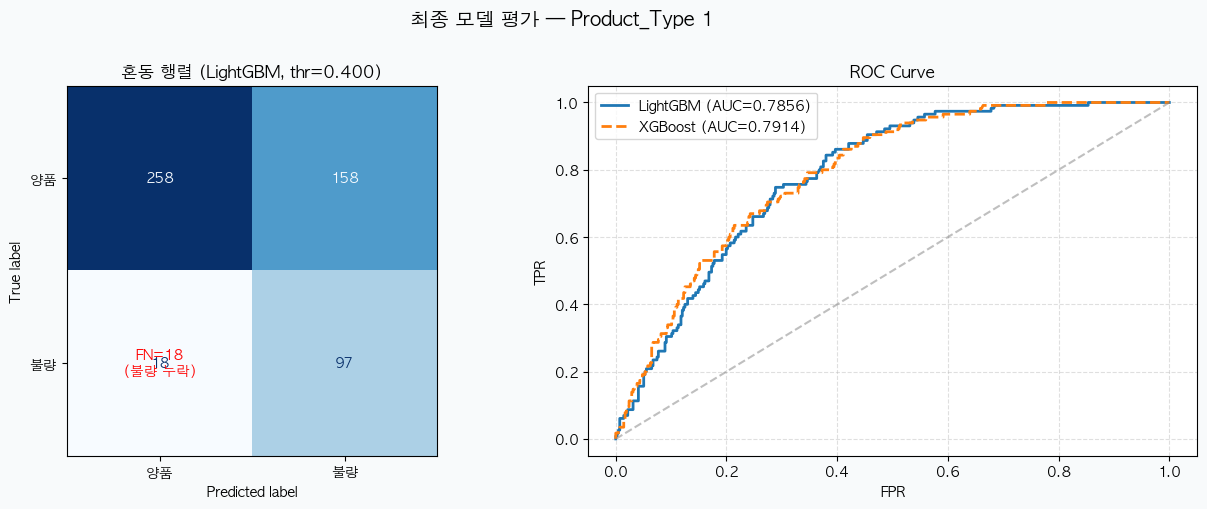

In [31]:
# 최종 평가 — LightGBM
y_pred_final = (y_prob_lgbm >= opt_thr_lgbm).astype(int)

print("=" * 55)
print(f"  최종 모델: LightGBM (임계값 {opt_thr_lgbm:.3f})")
print("=" * 55)
print(classification_report(y_test, y_pred_final,
                            target_names=['양품','불량'], digits=4))

# 혼동행렬 + ROC
fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_lgbm)
fpr_x, tpr_x, _ = roc_curve(y_test, y_prob_xgb)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#F8FAFB')

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=['양품','불량']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
tn,fp,fn,tp = cm.ravel()
axes[0].set_title(f'혼동 행렬 (LightGBM, thr={opt_thr_lgbm:.3f})', fontweight='bold')
axes[0].text(0, 1, f'FN={fn}\n(불량 누락)', ha='center', va='center',
             fontsize=10, color='red', fontweight='bold')

axes[1].plot(fpr_l, tpr_l, lw=2, label=f'LightGBM (AUC={roc_auc_score(y_test,y_prob_lgbm):.4f})')
axes[1].plot(fpr_x, tpr_x, lw=2, linestyle='--', label=f'XGBoost (AUC={roc_auc_score(y_test,y_prob_xgb):.4f})')
axes[1].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(linestyle='--', alpha=0.4)

plt.suptitle('최종 모델 평가 — Product_Type 1',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## STEP 16. SHAP 변수 중요도 분석

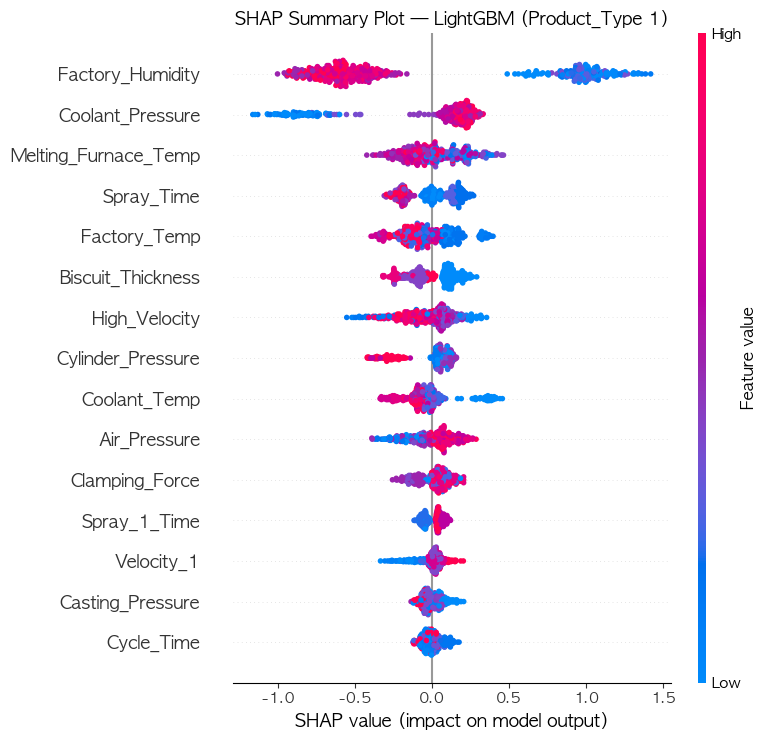


🏆 불량 예측 핵심 변수 TOP 5 (Product_Type 1):
   #1  Factory_Humidity           SHAP=0.7297
   #2  Coolant_Pressure           SHAP=0.3139
   #3  Melting_Furnace_Temp       SHAP=0.1405
   #4  Spray_Time                 SHAP=0.1375
   #5  Factory_Temp               SHAP=0.1342


In [32]:
explainer   = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test, feature_names=FEATURES, max_display=15, show=False)
plt.title('SHAP Summary Plot — LightGBM (Product_Type 1)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=FEATURES).sort_values(ascending=False)
print("\n🏆 불량 예측 핵심 변수 TOP 5 (Product_Type 1):")
for i, (var, val) in enumerate(mean_abs_shap.head(5).items(), 1):
    print(f"   #{i}  {var:<25}  SHAP={val:.4f}")

## STEP 17. 전체 결과 요약 및 모델 저장

In [33]:
def eval_with_threshold(name, group, y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    return {
        '모델': name, '구분': group, '임계값': round(float(thr),4),
        'Recall':    round(recall_score(y_true, y_pred, zero_division=0),4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0),4),
        'F1-Score':  round(f1_score(y_true, y_pred, zero_division=0),4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob),4),
        'Recall≥0.80': '✅' if recall_score(y_true, y_pred, zero_division=0) >= 0.80 else '❌'
    }

all_results = []
for name, model in baseline_models.items():
    if name == 'XGBoost':
        yp = model.predict_proba(X_test_xgb)[:,1]
    else:
        yp = model.predict_proba(X_test)[:,1]
    thr,_,_,_,_ = find_best_threshold_constrained(y_test, yp)
    all_results.append(eval_with_threshold(name, '베이스라인', y_test, yp, thr))

all_results.append(eval_with_threshold('LightGBM (튜닝)', '튜닝', y_test, y_prob_lgbm, opt_thr_lgbm))
all_results.append(eval_with_threshold('XGBoost  (튜닝)', '튜닝', y_test, y_prob_xgb,  opt_thr_xgb))

final_df = pd.DataFrame(all_results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
display(final_df)

with open('model_type1_lgbm.pkl', 'wb') as f:
    pickle.dump({'model': best_lgbm, 'threshold': float(opt_thr_lgbm), 'features': FEATURES}, f)

print("\n💾 모델 저장 완료: model_type1_lgbm.pkl")
best_row = final_df[final_df['모델']=='LightGBM (튜닝)'].iloc[0]
print(f"\n🏆 최종 선택: LightGBM (튜닝 + Constrained 임계값)")
print(f"   Recall  : {best_row['Recall']}")
print(f"   F1-Score: {best_row['F1-Score']}")
print(f"   ROC-AUC : {best_row['ROC-AUC']}")

,모델,구분,임계값,Recall,Precision,F1-Score,ROC-AUC,Recall≥0.80
0,LightGBM (튜닝),튜닝,0.40,0.8435,0.3804,0.5243,0.7856,✅
1,Logistic Regression,베이스라인,0.47,0.8087,0.3827,0.5196,0.7750,✅
2,XGBoost (튜닝),튜닝,0.36,0.8435,0.3660,0.5105,0.7914,✅
3,LightGBM,베이스라인,0.06,0.7043,0.3932,0.5047,0.7644,❌
4,XGBoost,베이스라인,0.13,0.6609,0.4043,0.5017,0.7393,❌
5,Random Forest,베이스라인,0.15,0.8087,0.3470,0.4856,0.7612,✅



💾 모델 저장 완료: model_type1_lgbm.pkl

🏆 최종 선택: LightGBM (튜닝 + Constrained 임계값)
   Recall  : 0.8435
   F1-Score: 0.5243
   ROC-AUC : 0.7856
